In [1]:
#Run this cell for markdown formatting assistance. This is not a part of the assignment.

from IPython.core.display import HTML
table_css = 'table {align:left;display:block} '
HTML('<style>{}</style>'.format(table_css))

# DSE 230: Analytics Assignment 3 - EDA on Airline Data

#### Submission on Gradescope:
  * You need to submit the following two files under "PA3". Instructions to generate the csv files are given in their respective sections **(please keep the file names as shown below in bold)**
      * The current notebook - **PA3_Starter.ipynb** - with all cells executed
      * csv file containing the top 50 rows of the input dataframe with transformed columns 'MONTH' and 'DAY_OF_WEEK' and filtered such that only weekend flights from the carrier with the most extreme weekend delays are present + column header - **50_rows.csv**
      
#### IMPORTANT submission guidelines enforced by autograder. Please read carefully:
  * Make sure that all the cells in this notebook are executed and that the outputs are present in the expected cells before submission
  * Some cells are marked **DO NOT DELETE**. These cells cannot be deleted and the output of these cells will be used for autograding
  * You can add additional cells, but the **Expected Output** for each of the tasks MUST be the output of the cells marked as such
  * DO NOT print anything other than the *exact* expected output. **Do not include any sentences/words describing the output**. This is strictly enforced by the autograder which checks for an *exact* match of the expected output. For example, if you are expected to print the PySpark version:
      * '10.9.8' - <span style="color:#093">CORRECT</span>
      * 'The PySpark version is 10.9.8' - <span style="color:#FF0000">INCORRECT</span>
  * You can add cells for printing debugging information anywhere, but do not print anything else in **Expected Output** cells other than the expected output for the task
  *   * Guidelines for displaying contents of a dataframe in the notebook - Enforced by the autograder:
    * Do NOT use the print() function to show your output unless explicitly stated.
    * Use DataFrame.show() with appropriate arguments for n and truncate (only if explicitly stated), to display the entire cell contents of a dataframe in the notebook.
    * **Refrain from using DataFrame.head(n)** as it displays multi-column dataframes in an unintuitive way. This will be enforced by the autograder.
---

Remember: when in doubt, read the documentation first. It's always helpful to search for the class that you're trying to work with, e.g. pyspark.sql.DataFrame. 

PySpark API Documentation: https://spark.apache.org/docs/4.1.1/api/python/index.html

Spark DataFrame Guide:  https://spark.apache.org/docs/4.1.1/index.html

### General instructions for all plots (Important for Autograder)
1. All plots must have the given title and axes labels
2. Figure size (figsize) for all plots must be set to (10,8)
3. Keep the color of the plots and other style attributes set to default
4. Always do plt.show() at the end to display the plots

In [2]:
import matplotlib.pyplot as plt
import matplotlib

### 1. Start Spark Session

#### **Expected output**: None

In [3]:
# Suppress native-hadoop warning
!sed -i '$a\# Add the line for suppressing the NativeCodeLoader warning \nlog4j.logger.org.apache.hadoop.util.NativeCodeLoader=ERROR,console' /$HADOOP_HOME/etc/hadoop/log4j.properties
import os; os.close(os.dup2(os.open(os.devnull, os.O_WRONLY), 2))

In [4]:
# Change the number of cores in this code block
# by setting `spark.master` to `local[n]` where
# n is the number of cores
import pyspark
from pyspark.sql import SparkSession
conf = pyspark.SparkConf().setAll([('spark.master', 'local[4]'),
                                   ('spark.app.name', 'Spark Demo')])
spark = SparkSession.builder.config(conf=conf).getOrCreate()

In [5]:
pyspark.__version__

'4.1.1'

### 2. Set Schema & Load Data - 0.5 points
Define schema for the data file according to the following data types. 
- Integer: '_c0', 'OP_CARRIER_FL_NUM'
- Date: 'FL_DATE' 
- String: 'OP_CARRIER', 'ORIGIN', 'DEST', 'CANCELLATION_CODE'
- Double: 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'


**The columns must be defined in the schema in exactly the order they appear below** (this must match the column order in the CSV file):

`['_c0', 'FL_DATE', 'OP_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']`

**Important**: Define the `StructField` entries in your `StructType` in the **exact same order** as listed above. The order must match the column order in the CSV file, otherwise the schema will be applied incorrectly.

- Many time-related columns are set to double because they need further processing before they can be converted to datetime
- All columns can have NULL values
- Useful links: [pyspark.sql.types.StructField](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.types.StructField.html), [pyspark.sql.types.StructType](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.types.StructType.html), [DataTypes](https://spark.apache.org/docs/latest/sql-ref-datatypes.html)

Read data from the `Airline_2016_2018.csv` file using the defined schema and select only 'FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DISTANCE', 'CANCELLED', 'ARR_DELAY' fields.

Note: The given csv file is zipped and it needs to be unzipped before it can be loaded.

#### **Expected output**: Schema of the dataframe after selecting 'FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DISTANCE', 'CANCELLED', 'ARR_DELAY' fields

In [10]:
from pyspark.sql.types import StructType, StructField, IntegerType, DateType, StringType, DoubleType

schema = StructType([
    StructField('_c0', IntegerType(), True),
    StructField('FL_DATE', DateType(), True),
    StructField('OP_CARRIER', StringType(), True),
    StructField('OP_CARRIER_FL_NUM', IntegerType(), True),
    StructField('ORIGIN', StringType(), True),
    StructField('DEST', StringType(), True),
    StructField('CRS_DEP_TIME', DoubleType(), True),
    StructField('DEP_TIME', DoubleType(), True),
    StructField('DEP_DELAY', DoubleType(), True),
    StructField('TAXI_OUT', DoubleType(), True),
    StructField('WHEELS_OFF', DoubleType(), True),
    StructField('WHEELS_ON', DoubleType(), True),
    StructField('TAXI_IN', DoubleType(), True),
    StructField('CRS_ARR_TIME', DoubleType(), True),
    StructField('ARR_TIME', DoubleType(), True),
    StructField('ARR_DELAY', DoubleType(), True),
    StructField('CANCELLED', DoubleType(), True),
    StructField('CANCELLATION_CODE', StringType(), True),
    StructField('DIVERTED', DoubleType(), True),
    StructField('CRS_ELAPSED_TIME', DoubleType(), True),
    StructField('ACTUAL_ELAPSED_TIME', DoubleType(), True),
    StructField('AIR_TIME', DoubleType(), True),
    StructField('DISTANCE', DoubleType(), True),
    StructField('CARRIER_DELAY', DoubleType(), True),
    StructField('WEATHER_DELAY', DoubleType(), True),
    StructField('NAS_DELAY', DoubleType(), True),
    StructField('SECURITY_DELAY', DoubleType(), True),
    StructField('LATE_AIRCRAFT_DELAY', DoubleType(), True)
])

df = spark.read.csv('hdfs:///Airline_2016_2018.csv', header=True, schema=schema)
df = df.select('FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DISTANCE', 'CANCELLED', 'ARR_DELAY')
df.printSchema()
    

root
 |-- FL_DATE: date (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DISTANCE: double (nullable = true)
 |-- CANCELLED: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)



### 3. Clean the data - 0.5 points

##### Task:
1. Remove all cancelled flights (where 'CANCELLED' = 0 means not cancelled) and remove rows with any empty values.
2. Drop the 'CANCELLED' column from the DataFrame (it is no longer needed after filtering).

Note: 'CANCELLED' = 0 shows that the flight is not cancelled

##### Expected output:
The first 25 rows of the cleaned dataframe

#### Pass `truncate=False` as an argument to `DataFrame.show` to show the entire output.


In [11]:
df = df.filter(df.CANCELLED == 0).dropna()
df = df.drop('CANCELLED')
df.show(25, truncate=False)

+----------+----------+------+--------+---------+
|FL_DATE   |OP_CARRIER|ORIGIN|DISTANCE|ARR_DELAY|
+----------+----------+------+--------+---------+
|2016-01-01|DL        |DTW   |1979.0  |-24.0    |
|2016-01-01|DL        |ATL   |640.0   |-2.0     |
|2016-01-01|DL        |LAX   |1947.0  |-13.0    |
|2016-01-01|DL        |SLC   |1590.0  |-16.0    |
|2016-01-01|DL        |BZN   |874.0   |124.0    |
|2016-01-01|DL        |ATL   |214.0   |83.0     |
|2016-01-01|DL        |BNA   |214.0   |74.0     |
|2016-01-01|DL        |ATL   |270.0   |3.0      |
|2016-01-01|DL        |JAX   |270.0   |-15.0    |
|2016-01-01|DL        |ATL   |761.0   |-12.0    |
|2016-01-01|DL        |MSP   |1517.0  |-33.0    |
|2016-01-01|DL        |LAX   |2475.0  |-14.0    |
|2016-01-01|DL        |ATL   |620.0   |-11.0    |
|2016-01-01|DL        |MDT   |620.0   |-15.0    |
|2016-01-01|DL        |SLC   |1990.0  |6.0      |
|2016-01-01|DL        |SAV   |214.0   |-18.0    |
|2016-01-01|DL        |BUF   |712.0   |6.0      |


### 4. Date/time transformations - 0.5 points

##### Tasks
1. Get the day of week (ranging from 1 for a Sunday to a 7 for Saturday) for each row and store it in a column named 'DAY_OF_WEEK'
1. Get the month for each row from the column FL_DATE, cast it to [ShortType](https://spark.apache.org/docs/latest/sql-ref-datatypes.html) and store it in column 'MONTH'

Note: The column 'FL_DATE' has date in YYYY-MM-DD format

Useful functions - [pyspark.sql.functions.dayofweek](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.functions.dayofweek.html), [pyspark.sql.functions.split](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.functions.split.html), [pyspark.sql.Column.cast](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.Column.cast.html)

##### **Expected output** -  The top 25 rows of the transformed dataframe with columns 'FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DISTANCE', 'ARR_DELAY', 'DAY_OF_WEEK', 'MONTH'
Your output should look like this: 

|   FL_DATE|OP_CARRIER|ORIGIN|DISTANCE|ARR_DELAY|DAY_OF_WEEK|MONTH|
| ---------|----------|------|--------|---------|-----------|-----|
|2016-01-01|        DL|   DTW|  1979.0|    -24.0|          6|    1|
|2016-01-01|        DL|   ATL|   640.0|     -2.0|          6|    1|

..23 more


(make sure that column sequence is same)

#### Pass `truncate=False` as an argument to `DataFrame.show` to show the entire output.


In [12]:
# DO NOT DELETE THIS CELL
from pyspark.sql.functions import dayofweek, split
from pyspark.sql.types import ShortType

df = df.withColumn('DAY_OF_WEEK', dayofweek('FL_DATE'))
df = df.withColumn('MONTH', split('FL_DATE', '-')[1].cast(ShortType()))
df.select('FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DISTANCE', 'ARR_DELAY', 'DAY_OF_WEEK', 'MONTH').show(25, truncate=False)

+----------+----------+------+--------+---------+-----------+-----+
|FL_DATE   |OP_CARRIER|ORIGIN|DISTANCE|ARR_DELAY|DAY_OF_WEEK|MONTH|
+----------+----------+------+--------+---------+-----------+-----+
|2016-01-01|DL        |DTW   |1979.0  |-24.0    |6          |1    |
|2016-01-01|DL        |ATL   |640.0   |-2.0     |6          |1    |
|2016-01-01|DL        |LAX   |1947.0  |-13.0    |6          |1    |
|2016-01-01|DL        |SLC   |1590.0  |-16.0    |6          |1    |
|2016-01-01|DL        |BZN   |874.0   |124.0    |6          |1    |
|2016-01-01|DL        |ATL   |214.0   |83.0     |6          |1    |
|2016-01-01|DL        |BNA   |214.0   |74.0     |6          |1    |
|2016-01-01|DL        |ATL   |270.0   |3.0      |6          |1    |
|2016-01-01|DL        |JAX   |270.0   |-15.0    |6          |1    |
|2016-01-01|DL        |ATL   |761.0   |-12.0    |6          |1    |
|2016-01-01|DL        |MSP   |1517.0  |-33.0    |6          |1    |
|2016-01-01|DL        |LAX   |2475.0  |-14.0    

#### **Expected output** -  The datatypes of all the columns in the resultant DataFrame

**NOTE**: This is not the same as the schema of the DataFrame

Useful function - [pyspark.sql.DataFrame.dtypes](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.dtypes.html)


In [13]:
print(df.dtypes)

[('FL_DATE', 'date'), ('OP_CARRIER', 'string'), ('ORIGIN', 'string'), ('DISTANCE', 'double'), ('ARR_DELAY', 'double'), ('DAY_OF_WEEK', 'int'), ('MONTH', 'smallint')]


## USE THE CLEANED/TRANSFORMED DATAFRAME FROM Q4.1 FOR ALL FOLLOWING QUESTIONS (AS OPPOSED TO THE ORIGINAL DATAFRAME LOADED IN Q2)

### 5. Analyze Weekend Flight Patterns - 2.5 points

#### 5.1 - Plot weekend vs weekday flight volumes (1 point)

##### Tasks
1. Create a new column 'DAY_TYPE' with values:
   - "Weekend" if DAY_OF_WEEK is 1 (Sunday) or 7 (Saturday)
   - "Weekday" if DAY_OF_WEEK is 2-6 (Monday-Friday)
   - Be sure to use this exact spelling and casing (e.g. W is in caps in Weekday)
   - This resulting dataframe will be used in step 7.1
2. Count total flights for each day type
3. Plot bar chart 


Useful functions - [pyspark.sql.functions.when](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.functions.when.html), [pyspark.sql.functions.col](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.functions.col.html), [pyspark.sql.DataFrame.groupBy](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.groupBy.html)

##### **Expected output**

DataFrame showing day type and count with column names 'DAY_TYPE' and 'count'

#### Pass `truncate=False` as an argument to `DataFrame.show` to show the entire output.

In [16]:
from pyspark.sql.functions import when, col

df = df.withColumn('DAY_TYPE', when((col('DAY_OF_WEEK') == 1) | (col('DAY_OF_WEEK') == 7), 'Weekend').otherwise('Weekday'))

day_type_counts = df.groupBy('DAY_TYPE').count()
day_type_counts.show(truncate=False)

+--------+--------+
|DAY_TYPE|count   |
+--------+--------+
|Weekday |13403792|
|Weekend |4790169 |
+--------+--------+



Useful functions - [matplotlib.pyplot.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)
##### **Expected output** 

A bar chart titled 'Flight volume: Weekends vs Weekdays' with x-axis label as 'Day Type' and y-axis label as 'No. of Flights'. 

NOTE: Size your plot using: plt.figure(figsize=(10,8)) , Use this sizing command for all subsequent plots

**[REFER TO THE FOLLOWING SECTION FOR PLOT INSTRUCTIONS](#General-instructions-for-all-plots-(Important-for-Autograder))**


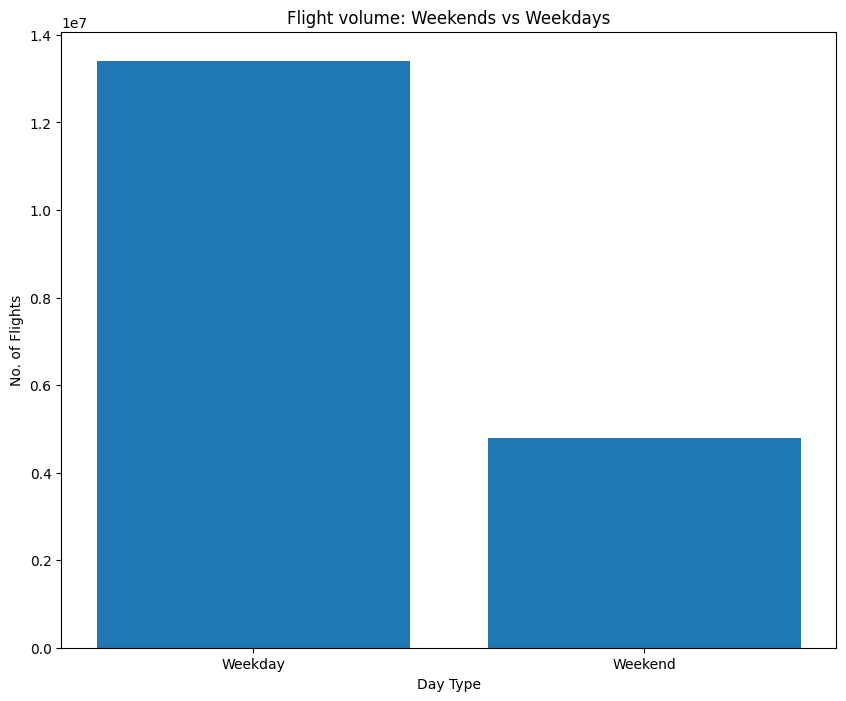

In [17]:
day_type_pd = day_type_counts.toPandas()
plt.figure(figsize=(10, 8))
plt.bar(day_type_pd['DAY_TYPE'], day_type_pd['count'])
plt.title('Flight volume: Weekends vs Weekdays')
plt.xlabel('Day Type')
plt.ylabel('No. of Flights')
plt.show()

#### 5.2 - Plot average arrival delay: Weekend vs Weekday (1.5 points)

##### Tasks
Using the dataframe with 'DAY_TYPE' column from 5.1
1. Calculate average ARR_DELAY for Weekend vs Weekday and sort by 'DAY_TYPE'
2. Plot bar chart comparing the two

Useful functions - [pyspark.sql.DataFrame.groupBy](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.groupBy.html), [pyspark.sql.functions.avg](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.functions.avg.html)



##### **Expected output** 

DataFrame with 'DAY_TYPE' and 'AVG_DELAY' columns, sorted by DAY_TYPE

#### Pass `truncate=False` as an argument to `DataFrame.show` to show the entire output.

In [19]:
from pyspark.sql.functions import avg

avg_delay = df.groupBy('DAY_TYPE').agg(avg('ARR_DELAY').alias('AVG_DELAY')).orderBy('DAY_TYPE')
avg_delay.show(truncate=False)

+--------+-----------------+
|DAY_TYPE|AVG_DELAY        |
+--------+-----------------+
|Weekday |4.913324751682211|
|Weekend |2.817746513745131|
+--------+-----------------+



##### **Expected output** 

A bar chart titled 'Average arrival delay: Weekends vs Weekdays' with x-axis label as 'Day Type' and y-axis label as 'Average Delay (minutes)'

Size your plot as mentioned before.

**[REFER TO THE FOLLOWING SECTION FOR PLOT INSTRUCTIONS](#General-instructions-for-all-plots-(Important-for-Autograder))**

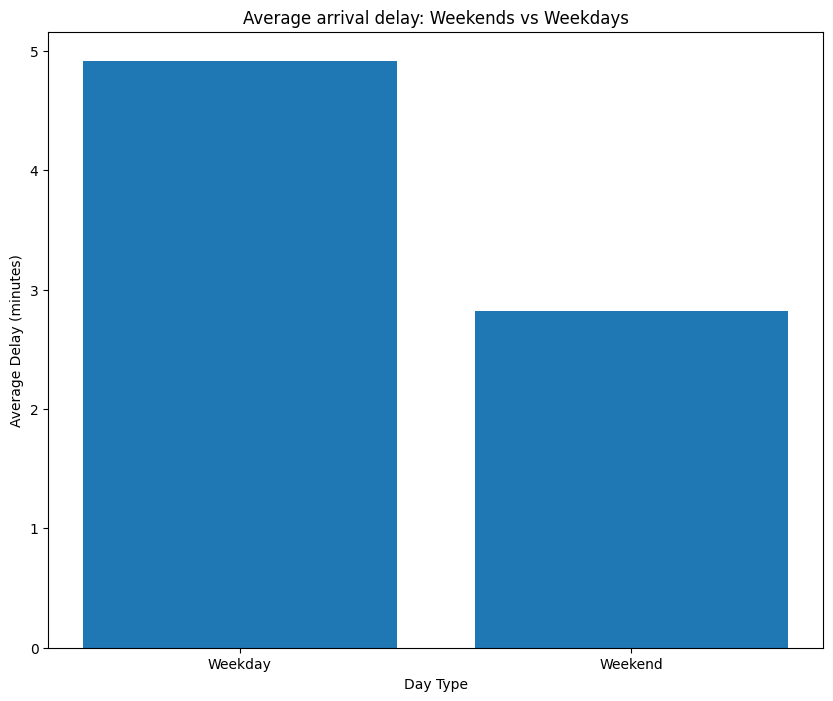

In [21]:
avg_delay_pd = avg_delay.toPandas()
plt.figure(figsize=(10, 8))
plt.bar(avg_delay_pd['DAY_TYPE'], avg_delay_pd['AVG_DELAY'])
plt.title('Average arrival delay: Weekends vs Weekdays')
plt.xlabel('Day Type')
plt.ylabel('Average Delay (minutes)')
plt.show()

### 6. Identify Top 10 Weekend-Heavy Carriers - 1 point

##### Tasks
1. For each carrier, calculate:
   - Total weekend flights [WEEKEND_FLIGHTS]
   - Total flights (weekend + weekday) [TOTAL_FLIGHTS]
   - Weekend percentage = (weekend flights / total flights) × 100 (Rounding not necessary)
2. Identify top 10 carriers with highest weekend flight percentage
   - This dataframe will be used in step 7.1
3. Plot pie chart of their total weekend flight counts

Useful functions - [pyspark.sql.DataFrame.filter](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.filter.html), [pyspark.sql.DataFrame.groupBy](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.groupBy.html), [pyspark.sql.DataFrame.join](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.join.html)

##### **Expected output** 

DataFrame with top 10 carriers showing 'OP_CARRIER', 'WEEKEND_FLIGHTS', 'TOTAL_FLIGHTS', 'WEEKEND_PCT', sorted by 'WEEKEND_PCT' descending

#### Pass `truncate=False` as an argument to `DataFrame.show` to show the entire output.

In [22]:
from pyspark.sql.functions import count

# wknd flights / carrier
weekend_flights = df.filter(col('DAY_TYPE') == 'Weekend').groupBy('OP_CARRIER').agg(count('*').alias('WEEKEND_FLIGHTS'))
 
# total flights / carrier
total_flights = df.groupBy('OP_CARRIER').agg(count('*').alias('TOTAL_FLIGHTS'))

# join & calc wknd %
carrier_df = weekend_flights.join(total_flights, on='OP_CARRIER')
carrier_df = carrier_df.withColumn('WEEKEND_PCT', (col('WEEKEND_FLIGHTS') / col('TOTAL_FLIGHTS')) * 100)

# top 10 by wknd %
top10 = carrier_df.orderBy(col('WEEKEND_PCT').desc()).limit(10)
top10.show(truncate=False)

+----------+---------------+-------------+------------------+
|OP_CARRIER|WEEKEND_FLIGHTS|TOTAL_FLIGHTS|WEEKEND_PCT       |
+----------+---------------+-------------+------------------+
|G4        |27914          |95192        |29.323892764097824|
|NK        |134096         |460968       |29.090088682945453|
|HA        |69168          |239823       |28.841270436947248|
|F9        |89863          |313232       |28.68895898247944 |
|AS        |167400         |602048       |27.805091952801103|
|B6        |239930         |865396       |27.724879708249173|
|YV        |57265          |209094       |27.387203841334518|
|AA        |722418         |2683157      |26.92417924109547 |
|OH        |71517          |265784       |26.907940282334526|
|WN        |1025091        |3921112      |26.14286457515113 |
+----------+---------------+-------------+------------------+



##### **Expected output** 

A pie chart titled 'Weekend flight distribution among top 10 weekend-heavy carriers'

Size your plot as mentioned before.

**[REFER TO THE FOLLOWING SECTION FOR PLOT INSTRUCTIONS](#General-instructions-for-all-plots-(Important-for-Autograder))**

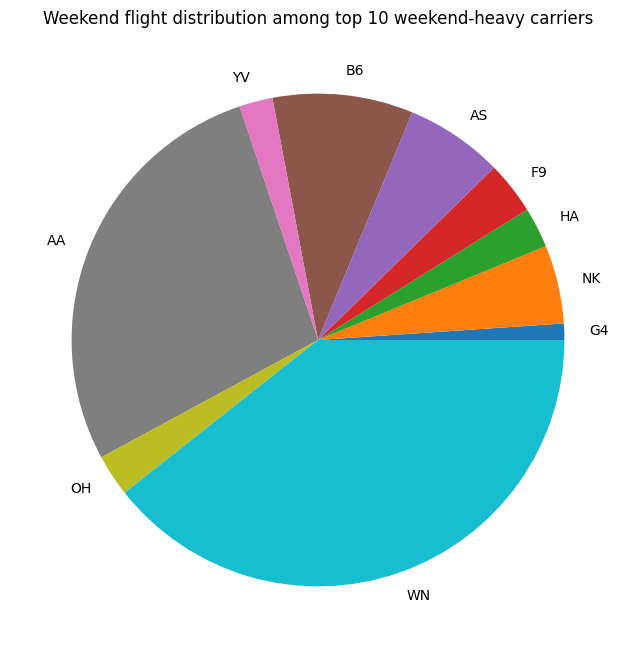

In [23]:
top10_pd = top10.toPandas()
plt.figure(figsize=(10, 8))
plt.pie(top10_pd['WEEKEND_FLIGHTS'], labels=top10_pd['OP_CARRIER'])
plt.title('Weekend flight distribution among top 10 weekend-heavy carriers')
plt.show()

### 7. Analyze Weekend Delays for Weekend-Heavy Carriers - 4 points

#### 7.1 - Filter for weekend-heavy carriers (1 point)

##### Tasks
1. Filter the original dataframe (with DAY_TYPE column from 5.1) to include *only* the top 10 weekend-heavy carriers identified in Question 6
2. Show first 25 rows

Useful functions - [pyspark.sql.DataFrame.filter](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.filter.html), [pyspark.sql.Column.isin](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.Column.isin.html)

**Hint**: To filter rows where a column's value is in a set of allowed values, use `.isin()` on the column

##### **Expected output** 

The top 25 rows of the filtered dataframe containing only flights from the top 10 weekend-heavy carriers

#### Pass `truncate=False` as an argument to `DataFrame.show` to show the entire output.

In [24]:
top10_carriers = top10_pd['OP_CARRIER'].tolist()
filtered_df = df.filter(col('OP_CARRIER').isin(top10_carriers))
filtered_df.show(25, truncate=False)

+----------+----------+------+--------+---------+-----------+-----+--------+
|FL_DATE   |OP_CARRIER|ORIGIN|DISTANCE|ARR_DELAY|DAY_OF_WEEK|MONTH|DAY_TYPE|
+----------+----------+------+--------+---------+-----------+-----+--------+
|2016-01-01|AS        |DCA   |2329.0  |-48.0    |6          |1    |Weekday |
|2016-01-01|AS        |SEA   |2329.0  |26.0     |6          |1    |Weekday |
|2016-01-01|AS        |DCA   |2329.0  |-25.0    |6          |1    |Weekday |
|2016-01-01|AS        |SEA   |2329.0  |19.0     |6          |1    |Weekday |
|2016-01-01|AS        |DCA   |2311.0  |-24.0    |6          |1    |Weekday |
|2016-01-01|AS        |LAX   |2311.0  |-9.0     |6          |1    |Weekday |
|2016-01-01|AS        |JFK   |2422.0  |-12.0    |6          |1    |Weekday |
|2016-01-01|AS        |SEA   |2402.0  |10.0     |6          |1    |Weekday |
|2016-01-01|AS        |SEA   |2554.0  |-12.0    |6          |1    |Weekday |
|2016-01-01|AS        |EWR   |2402.0  |-48.0    |6          |1    |Weekday |

#### 7.2 - Filter for weekend flights only (0.5 point)

##### Tasks
1. From the dataframe in 7.1, filter to keep only weekend flights (DAY_OF_WEEK = 1 or 7)
2. Show first 25 rows

Useful functions - [pyspark.sql.DataFrame.filter](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.filter.html)

##### **Expected output** 

First 25 rows of dataframe filtered for weekend flights only from the top 10 weekend-heavy carriers

#### Pass `truncate=False` as an argument to `DataFrame.show` to show the entire output.

In [25]:
# DO NOT DELETE THIS CELL
from pyspark.sql.functions import col

weekend_df = filtered_df.filter((col('DAY_OF_WEEK') == 1) | (col('DAY_OF_WEEK') == 7))
weekend_df.show(25, truncate=False)

+----------+----------+------+--------+---------+-----------+-----+--------+
|FL_DATE   |OP_CARRIER|ORIGIN|DISTANCE|ARR_DELAY|DAY_OF_WEEK|MONTH|DAY_TYPE|
+----------+----------+------+--------+---------+-----------+-----+--------+
|2016-01-02|AA        |DTW   |986.0   |-33.0    |7          |1    |Weekend |
|2016-01-02|AA        |SEA   |2422.0  |11.0     |7          |1    |Weekend |
|2016-01-02|AA        |JFK   |2422.0  |56.0     |7          |1    |Weekend |
|2016-01-02|AA        |ORD   |1829.0  |-30.0    |7          |1    |Weekend |
|2016-01-02|AA        |PHX   |868.0   |-4.0     |7          |1    |Weekend |
|2016-01-02|AA        |STL   |550.0   |-10.0    |7          |1    |Weekend |
|2016-01-02|AA        |DFW   |550.0   |-6.0     |7          |1    |Weekend |
|2016-01-02|AA        |LAX   |2311.0  |-24.0    |7          |1    |Weekend |
|2016-01-02|AA        |ORD   |1012.0  |-2.0     |7          |1    |Weekend |
|2016-01-02|AA        |MCO   |1005.0  |-9.0     |7          |1    |Weekend |

#### 7.3 - Calculate extreme delay counts on weekends (1 point)

##### Tasks
1. Using the weekend flights from 7.2, filter for extreme delays (ARR_DELAY > 90 minutes)
2. Count the number of extremely delayed flights for each carrier
3. Sort by count in descending order

Useful functions - [pyspark.sql.DataFrame.filter](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.filter.html), [pyspark.sql.DataFrame.groupBy](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.groupBy.html), [pyspark.sql.functions.count](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.functions.count.html)

##### **Expected output** 

DataFrame showing 'OP_CARRIER' and 'count' for extreme weekend delays, sorted descending by count

#### Pass `truncate=False` as an argument to `DataFrame.show` to show the entire output.

In [26]:
extreme_delays = weekend_df.filter(col('ARR_DELAY') > 90)\
    .groupBy('OP_CARRIER')\
    .count()\
    .orderBy(col('count').desc())
extreme_delays.show(truncate=False)

+----------+-----+
|OP_CARRIER|count|
+----------+-----+
|AA        |24343|
|WN        |23027|
|B6        |13932|
|NK        |5510 |
|F9        |5368 |
|OH        |3391 |
|YV        |2570 |
|AS        |2482 |
|G4        |1527 |
|HA        |543  |
+----------+-----+



#### 7.4 - Plot extreme weekend delay counts (1 point)

##### Tasks
1. Create a bar plot of extreme delay counts from 7.3
2. Follow plotting guidelines

Useful functions - [matplotlib.pyplot.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)

##### **Expected output** 

A bar chart titled 'Extreme delays (>90 min) on weekends for top 10 weekend-heavy carriers' with x-axis labeled as 'Carrier' and y-axis labeled as 'No. of flights'

Size your plot as mentioned before.

**[REFER TO THE FOLLOWING SECTION FOR PLOT INSTRUCTIONS](#General-instructions-for-all-plots-(Important-for-Autograder))**

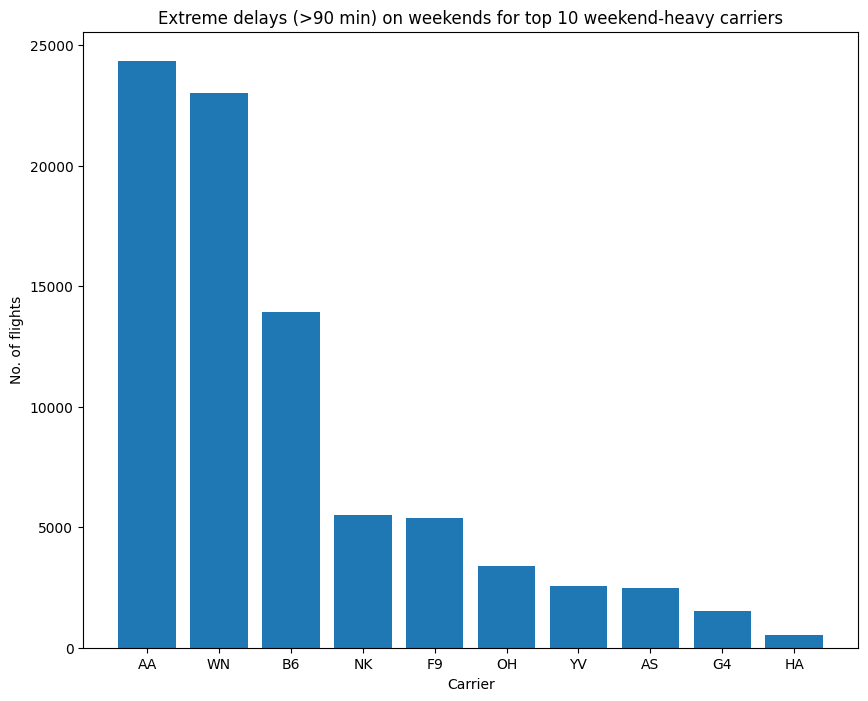

In [27]:
extreme_delays_pd = extreme_delays.toPandas()
plt.figure(figsize=(10, 8))
plt.bar(extreme_delays_pd['OP_CARRIER'], extreme_delays_pd['count'])
plt.title('Extreme delays (>90 min) on weekends for top 10 weekend-heavy carriers')
plt.xlabel('Carrier')
plt.ylabel('No. of flights')
plt.show()

#### 7.5 - Filter for carrier with most extreme weekend delays and save to CSV (0.5 points)

##### Tasks
1. From the weekend flights dataframe (7.2), filter to get only flights from the carrier with the highest count of extreme weekend delays (identified in 7.3)
2. Coalesce to 1 partition
3. Save as CSV to local filesystem
4. Extract first 50 rows + header to submit as 50_rows.csv

Useful functions - [pyspark.sql.DataFrame.filter](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.filter.html), [pyspark.sql.DataFrame.coalesce](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.coalesce.html), [pyspark.sql.DataFrameWriter.csv](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrameWriter.csv.html)

**REMINDER**: The results are saved to your local filesystem and the folder where you executed your launch script is mapped to the '/home/work' directory in your Docker container.

##### **Expected output**: None (in notebook)

##### **Expected output** (in 50_rows.csv file): 
First 50 rows of weekend flights from the carrier with the most extreme weekend delays + column header

Columns: 'FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DISTANCE', 'ARR_DELAY', 'DAY_OF_WEEK', 'MONTH'

In [28]:
# get carrier with most extreme wknd delays
top_carrier = extreme_delays.first()['OP_CARRIER']

# filter weekend_df for carrier
top_carrier_df = weekend_df.filter(col('OP_CARRIER') == top_carrier)

# required columns
top_carrier_df = top_carrier_df.select('FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DISTANCE', 'ARR_DELAY', 'DAY_OF_WEEK', 'MONTH')

# save to local
top_carrier_df.coalesce(1).write.csv('file:///home/PA3/top_carrier_results.csv', header=True, mode='overwrite')


The resultant file saved in the step above is actually a folder, which contains individually saved files from each partition of the saved dataframe. <br> <br>
Now, use a command to show the contents of the resulting folder on your local filesystem from the last step in the cell below. <br>
You will need to include ‘!’ before the command for Jupyter Notebook to recognize it as an operating system command. For instance '! pwd' displays the path name of your current directory.

In [32]:
! pwd

/home/PA3


#### **Expected output**: List of files in the directory where results were written out by PySpark. You should see a 'SUCCESS' folder in this directory

In [33]:
!ls top_carrier_results.csv/

_SUCCESS  part-00000-bf8f9c9b-22c7-4a9f-96cf-f815efa57b71-c000.csv


Now, stop the spark session in the cell below
#### **Expected output**: None

In [34]:
spark.stop()

### 8. Submission of `50_rows.csv` - 1 point

#### **Expected output** (in the 50_rows.csv file) - Top 50 rows of weekend flights from the carrier with the most extreme weekend delays + column header

**NOTE** - No output is expected in the notebook

The csv file should have seven columns, `FL_DATE`, `OP_CARRIER`, `ORIGIN`, `DISTANCE`, `ARR_DELAY`, `DAY_OF_WEEK`, `MONTH`, in the first line and 50 more lines with the top 50 rows of the filtered dataframe.

In [36]:
!head -n 51 top_carrier_results.csv/part-00000-bf8f9c9b-22c7-4a9f-96cf-f815efa57b71-c000.csv > 50_rows.csv

In [37]:
!ls

50_rows.csv	       PA3_Starter-checkpoint.ipynb  top_carrier_results.csv
Airline_2016_2018.csv  PA3_Starter.ipynb
